# Environment Setup

## Pip the necessary library

In [ ]:
dataset_path = "/kaggle/input/datasets/changchoufang/cv-hw1-data" # please to change to your path

## Library import

In [ ]:
# -*- coding: utf-8 -*-
import os
import random
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

from torch.utils.data import DataLoader
from torchvision.datasets import ImageFolder
import timm
from tqdm import tqdm
from PIL import Image
import pandas as pd
import matplotlib.pyplot as plt
import torch.nn.functional as F
from torch.cuda.amp import GradScaler, autocast
from sklearn.metrics import confusion_matrix

## Set the random seed

In [ ]:
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
set_seed(42)

# Training for the student model

## Training config setting

In [5]:
#########################################
# =============== setting ===============
#########################################

# datasetpath (please to change to your path)
train_path = os.path.join(dataset_path, "cv_hw1_data/data/train")
val_path   = os.path.join(dataset_path, "cv_hw1_data/data/val")
test_path  = os.path.join(dataset_path, "cv_hw1_data/data/test")

BATCH_SIZE = 128
EPOCHS = 3
LR = 1e-3 
NUM_CLASSES = 100
EARLY_STOPPING = 1000

DEVICE = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

# augmentation hyperparameter
MIXUP_ALPHA = 0.4
AUG_PROB = 0.7

# the path of the model with the highest accuracy
BEST_MODEL_PATH = "best_model.pth"

# mixup or not
USE_MIXUP = True

# knowledge distillation hyperparameter
KD_T = 3.0               
KD_ALPHA = 0.5          

# The path of teacher model (please to change to your path)
TEACHER_WEIGHT_PATH = os.path.join(dataset_path, "teacher_model.pth")

## The function for model and dataset

In [6]:
#########################################
# ========== model build ==================
#########################################

def build_models():
    
    # Student
    student = timm.create_model(
        'seresnextaa101d_32x8d.sw_in12k_ft_in1k_288',
        pretrained=True,
        num_classes=NUM_CLASSES
    )

    # Teacher
    teacher = timm.create_model(
        'seresnextaa201d_32x8d.sw_in12k_ft_in1k_384',
        pretrained=False,
        num_classes=NUM_CLASSES
    )

    # Load the teacher weight
    if os.path.exists(TEACHER_WEIGHT_PATH):
        teacher.load_state_dict(torch.load(TEACHER_WEIGHT_PATH))
        print(f"Successfully loaded Teacher weights from {TEACHER_WEIGHT_PATH}")
    else:
        print(f"CRITICAL WARNING: Teacher weights not found at {TEACHER_WEIGHT_PATH}!")
        print("Student will be learning from an UNTRAINED teacher.")

    teacher = teacher.to(DEVICE)
    teacher.eval()
    for p in teacher.parameters():
        p.requires_grad = False
        
    return student, teacher

In [7]:
#########################################
# ========== Model Size =================
#########################################

def print_model_size(model):
    total = sum(p.numel() for p in model.parameters())
    print(f"Model Params: {total/1e6:.2f}M")

## Build the teacher and student model using the function above

In [8]:
# Build model and ensure its model size

stu_model, tea_model = build_models()

print_model_size(stu_model)
print_model_size(tea_model)

model.safetensors:   0%|          | 0.00/375M [00:00<?, ?B/s]

Successfully loaded Teacher weights from /kaggle/input/datasets/changchoufang/cv-hw1-data/teacher_model.pth
Model Params: 91.74M
Model Params: 147.55M


In [9]:
# Find the default transform and apply it to this dataset

data_config = timm.data.resolve_model_data_config(tea_model)

train_transform = timm.data.create_transform(**data_config, is_training=True, auto_augment='rand-m9-mstd0.5', re_prob=0.25)
val_transform   = timm.data.create_transform(**data_config, is_training=False)

train_dataset = ImageFolder(train_path, transform=train_transform)
val_dataset   = ImageFolder(val_path, transform=val_transform)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

print("Train images:", len(train_dataset))
print("Val images:", len(val_dataset))

Train images: 20724
Val images: 300


## The function of Training process

In [10]:
#########################################
# =============== Mixup =================
#########################################

def mixup(x, y, alpha):
    lam = np.random.beta(alpha, alpha)
    idx = torch.randperm(x.size(0)).to(DEVICE)
    return lam*x + (1-lam)*x[idx], y, y[idx], lam

In [11]:
#########################################
# ========== Gradual Unfreeze ===========
#########################################

def set_trainable_layers(model, stage, unfreeze_blocks=3):

    for p in model.parameters():
        p.requires_grad = False

    # ===== Stage 0: fc only =====
    if stage == 0:
        for p in model.fc.parameters():
            p.requires_grad = True

    # ===== Stage 1: layer4 + fc =====
    elif stage == 1:

        # fc 
        for p in model.fc.parameters():
            p.requires_grad = True

        # 開 layer 4 
        blocks = list(model.layer4.children())

        for block in blocks[-unfreeze_blocks:]: 
            for p in block.parameters(): 
                p.requires_grad = True

    # ===== Stage 2: layer3 (the last three blocks) + layer4 + fc =====
    elif stage == 2:

        # fc 
        for p in model.fc.parameters():
            p.requires_grad = True

        # layer 4 
        blocks = list(model.layer4.children())

        for block in blocks[-unfreeze_blocks:]: 
            for p in block.parameters(): 
                p.requires_grad = True

        # layer 3
        blocks = list(model.layer3.children())

        for block in blocks[-3:]: 
            for p in block.parameters(): 
                p.requires_grad = True

In [12]:
#########################################
# ===== show trainable parameters  ======
#########################################

def print_trainable_layers(model):
    print("==== Trainable Layers ====")
    total = 0
    trainable = 0

    for name, p in model.named_parameters():
        total += p.numel()
        if p.requires_grad:
            trainable += p.numel()
            print(name)

    print(f"\nTrainable params: {trainable:,}")
    print(f"Total params: {total:,}")
    print(f"Trainable ratio: {trainable/total:.4f}")

In [23]:
#########################################
# ===== KD Training + Evaluation ======
#########################################

def train_kd(student, teacher):
    
    PRINT = True # Debug flag for printing trainable layers

    # ===== Device Setup =====
    student = student.to(DEVICE)
    teacher = teacher.to(DEVICE)
    teacher.eval()  # Freeze teacher model

    # ===== Loss Functions =====
    criterion_ce = nn.CrossEntropyLoss(label_smoothing=0.05)  # Hard label loss
    criterion_kd = nn.KLDivLoss(reduction="batchmean")        # Soft label loss

    # ===== Optimizer (Student Only) =====
    optimizer = optim.AdamW([
        {"params": student.fc.parameters(), "lr": LR},
        {"params": student.layer4.parameters(), "lr": LR * 0.3},
        {"params": student.layer3.parameters(), "lr": LR * 0.1},
    ])

    # ===== Learning Rate Scheduler =====
    scheduler = optim.lr_scheduler.CosineAnnealingLR(
        optimizer, T_max=EPOCHS, eta_min=LR * 0.01
    )

    # ===== Mixed Precision Training =====
    scaler = torch.cuda.amp.GradScaler()

    # ===== Training Records =====
    best_acc = 0
    train_loss_list, val_loss_list = [], []
    train_acc_list, val_acc_list = [], []

    
    # =========================================
    # ============== Training Loop ============
    # =========================================
    for epoch in range(EPOCHS):
        print(f"\nEpoch {epoch+1}/{EPOCHS}")

        # ===== Gradual Unfreezing Strategy (for student) =====
        if epoch < int(0.3 * EPOCHS):
            set_trainable_layers(student, 0)
        elif epoch < int(0.6 * EPOCHS):
            if not PRINT and epoch == int(0.3 * EPOCHS):
                print(f"[INFO] Unfreezing additional layers at epoch {epoch}")
                PRINT = True
            set_trainable_layers(student, 0)
        else:
            if not PRINT and epoch == int(0.6 * EPOCHS):
                print(f"[INFO] Further unfreezing at epoch {epoch}")
                PRINT = True
            set_trainable_layers(student, 0)

        # ===== Mixup Augmentation Schedule =====
        if not USE_MIXUP:
            aug_prob = 0
        else:
            aug_prob = AUG_PROB if epoch < int(0.8 * EPOCHS) else 0

        # ===== Debug: Print trainable layers =====
        if PRINT:
            print_trainable_layers(student)
            PRINT = False

        # =========================================
        # ============== Batch Loop ===============
        # =========================================
        student.train()
        running_loss, correct, total = 0, 0, 0
        pbar = tqdm(train_loader, desc="KD Training")

        for images, labels in pbar:
            
            images, labels = images.to(DEVICE), labels.to(DEVICE)
            optimizer.zero_grad(set_to_none=True)

            with torch.cuda.amp.autocast():
                
                # ===== (1) Apply Mixup =====
                if USE_MIXUP and np.random.rand() < aug_prob:
                    images, y_a, y_b, lam = mixup(images, labels, MIXUP_ALPHA)
                    is_mixed = True
                else:
                    lam = 1.0
                    is_mixed = False

                # ===== (2) Teacher Forward Pass =====
                with torch.no_grad():
                    teacher_logits = teacher(images)

                # ===== (3) Student Forward Pass =====
                student_logits = student(images)

                # ===== (4) Hard Loss (Ground Truth) =====
                if is_mixed:
                    loss_hard = lam * criterion_ce(student_logits, y_a) + \
                                (1 - lam) * criterion_ce(student_logits, y_b)
                else:
                    loss_hard = criterion_ce(student_logits, labels)

                # ===== (5) Soft Loss (Distillation) =====
                soft_teacher = F.softmax(teacher_logits / KD_T, dim=1)
                soft_student = F.log_softmax(student_logits / KD_T, dim=1)
                loss_soft = criterion_kd(soft_student, soft_teacher) * (KD_T ** 2)

                # ===== (6) Total Loss =====
                loss = (1 - KD_ALPHA) * loss_hard + KD_ALPHA * loss_soft

            # ===== Backpropagation =====
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()

            # ===== Metrics =====
            running_loss += loss.item()
            _, pred = student_logits.max(1)
            total += labels.size(0)
            
            if is_mixed:
                correct += (lam * pred.eq(y_a).sum().item() + (1 - lam) * pred.eq(y_b).sum().item())
            else:
                correct += pred.eq(labels).sum().item()

            pbar.set_postfix({"loss": f"{loss.item():.4f}", "acc": f"{correct/total:.4f}"})

        scheduler.step()

        # ===== Training Statistics =====
        train_loss = running_loss / len(train_loader)
        train_acc = correct / total
        current_lr = optimizer.param_groups[0]['lr'] 

        train_loss_list.append(train_loss) 
        train_acc_list.append(train_acc)  
        
        # =========================================
        # ============== Validation ===============
        # =========================================
        student.eval()
        correct, total = 0, 0
        val_running_loss = 0

        ce_loss = nn.CrossEntropyLoss()

        with torch.no_grad():

            for images, labels in tqdm(val_loader, desc="Validation"):
                
                images, labels = images.to(DEVICE), labels.to(DEVICE)

                outputs = student(images)
                loss = ce_loss(outputs, labels)

                val_running_loss += loss.item()

                _, pred = outputs.max(1)
                total += labels.size(0)
                correct += pred.eq(labels).sum().item()

        val_loss = val_running_loss / len(val_loader)
        val_acc = correct / total

        val_loss_list.append(val_loss)
        val_acc_list.append(val_acc)

        print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | "
              f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f} | LR: {current_lr:.6f}")

        # ===== Save Best Model =====
        if val_acc >= best_acc:
            best_acc = val_acc
            torch.save(student.state_dict(), BEST_MODEL_PATH)
            print(f">>> Save Best Student Model (Acc: {val_acc:.4f})")

    return student, train_loss_list, val_loss_list, train_acc_list, val_acc_list

## Run the train process

In [14]:
stu_model, train_loss, val_loss, train_acc, val_acc = train_kd(stu_model, tea_model)


Epoch 1/3
==== Trainable Layers ====
fc.weight
fc.bias

Trainable params: 204,900
Total params: 91,744,180
Trainable ratio: 0.0022


Validation:  67%|██████▋   | 2/3 [00:22<00:11, 11.44s/it]


Train Loss: 0.0559 | Train Acc: 0.0000 | Val Loss: 4.7578 | Val Acc: 0.0133 | LR: 0.000753
>>> Save Best Student Model (Acc: 0.0133)

Epoch 2/3
[INFO] Further unfreezing at epoch 1
==== Trainable Layers ====
fc.weight
fc.bias

Trainable params: 204,900
Total params: 91,744,180
Trainable ratio: 0.0022


Validation:  67%|██████▋   | 2/3 [00:21<00:10, 10.77s/it]


Train Loss: 0.0676 | Train Acc: 0.0312 | Val Loss: 4.8704 | Val Acc: 0.0133 | LR: 0.000258
>>> Save Best Student Model (Acc: 0.0133)

Epoch 3/3


Validation:  67%|██████▋   | 2/3 [00:21<00:10, 10.96s/it]


Train Loss: 0.0638 | Train Acc: 0.0234 | Val Loss: 4.8941 | Val Acc: 0.0167 | LR: 0.000010
>>> Save Best Student Model (Acc: 0.0167)


## Training Curves Visualization

In [15]:
#########################################
# ====== Plot the training curve=========
#########################################

def plot_curve(train, val, title):

    plt.figure()
    plt.plot(train, label="train")
    plt.plot(val, label="val")
    plt.legend()
    plt.title(title)
    plt.show()

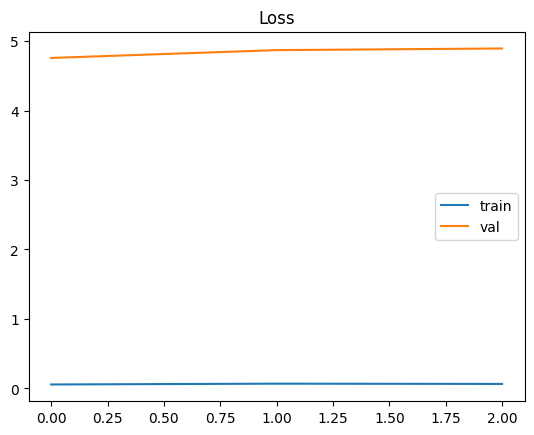

In [16]:
plot_curve(train_loss, val_loss, "Loss")

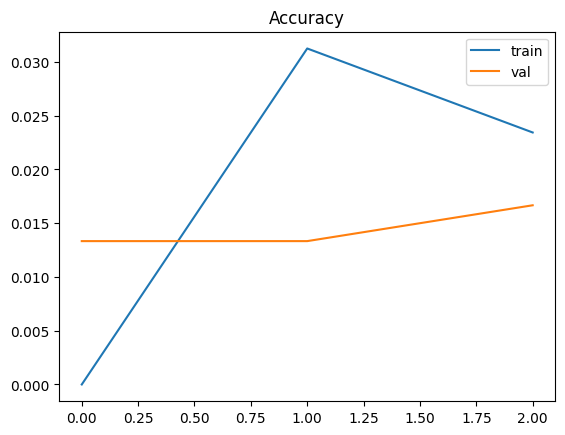

In [17]:
plot_curve(train_acc, val_acc, "Accuracy")

# Evaluate the best model by validation dataset

## The evaluation function

In [18]:
#########################################
# == Evaluation for validation dataset===
#########################################

def validate(model, val_loader, device):
    
    model.to(device)
    model.eval()

    all_preds = []
    all_labels = []

    val_running_loss = 0.0
    correct = 0
    total = 0

    criterion = nn.CrossEntropyLoss()

    with torch.no_grad():
        for images, labels in tqdm(val_loader, desc="Validation"):
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)

            # loss
            loss = criterion(outputs, labels)
            val_running_loss += loss.item()

            # prediction
            _, preds = outputs.max(1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

            # accuracy
            total += labels.size(0)
            correct += preds.eq(labels).sum().item()

    val_loss = val_running_loss / len(val_loader)
    val_acc = correct / total

    return val_loss, val_acc, all_preds, all_labels

In [19]:
#########################################
# ====== Plot the confusion matrix ======
#########################################

def plot_confusion_matrix(cm, title="Confusion Matrix", figsize=(12, 10)):
    plt.figure(figsize=figsize)
    sns.heatmap(cm, cmap="Blues")
    plt.title(title)
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.show()

## Run the evaluation process

In [21]:
# Load the best model from the best model checkpoint

stu_model.load_state_dict(torch.load(BEST_MODEL_PATH))
stu_model.to(DEVICE)
stu_model.eval();

In [22]:
# run the evaluation
val_loss, val_acc, val_preds, val_labels = validate(stu_model, val_loader, DEVICE)

print(f"Val Loss: {val_loss:.4f}")
print(f"Val Acc: {val_acc:.4f}")

Validation: 100%|██████████| 3/3 [00:22<00:00,  7.64s/it]

Val Loss: 4.8941
Val Acc: 0.0167


## Plot Confusion Matrix on Validation Set

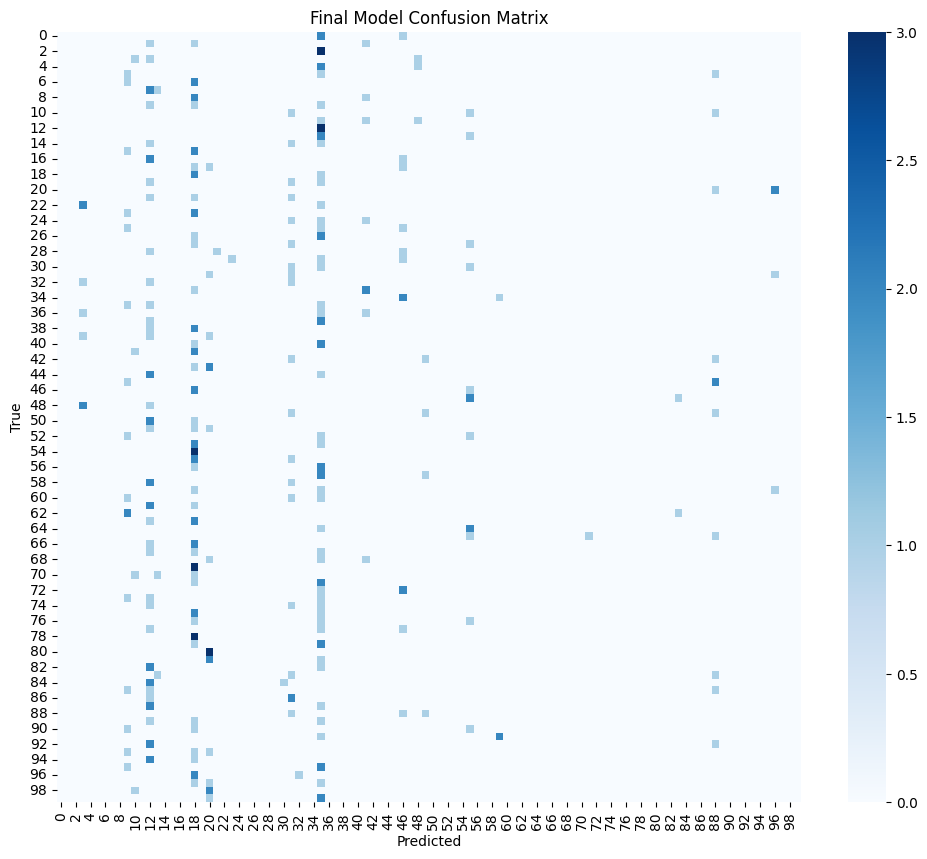

In [24]:
cm = confusion_matrix(val_labels, val_preds)
plot_confusion_matrix(cm, title="Final Model Confusion Matrix")

# Inference the test dataset

## The function of Inference

In [25]:
#########################################
# ===== Inference on Test Set =====
#########################################

def inference(model, path_name):

    # ===== Map prediction index back to original class label =====
    idx_to_class = {v: int(k) for k, v in train_dataset.class_to_idx.items()}

    # ===== Model setup =====
    model.to(DEVICE)
    model.eval()  # set to evaluation mode

    # ===== Load test file names =====
    test_files = sorted(os.listdir(test_path))

    results = []

    # =========================================
    # ============== Inference Loop ===========
    # =========================================
    for f in tqdm(test_files, desc="Testing"):

        # ----- Load and preprocess image -----
        img = Image.open(os.path.join(test_path, f)).convert("RGB")
        img = val_transform(img).unsqueeze(0).to(DEVICE)

        # ----- Forward pass (no gradient) -----
        with torch.no_grad():
            pred = model(img).argmax(1).item()

        # ----- Save result (image_id, predicted label) -----
        results.append([os.path.splitext(f)[0], idx_to_class[pred]])

    # ===== Save submission file =====
    pd.DataFrame(results, columns=["image_name", "pred_label"]).to_csv(path_name, index=False)

    print(f"{path_name} saved!")

## Run the inference process

In [ ]:
# run the inference
inference(stu_model, "best_prediction.csv")